# Plagiarism Detection — N-gram Shingling + Cosine Similarity
### Detectron AI · Module 10

This notebook implements two real document-similarity techniques: **N-gram shingling
with Jaccard similarity** (the same method used in the live web demo, and historically
in tools like MOSS) and **TF-IDF cosine similarity** (the standard approach in modern
plagiarism-detection pipelines), then compares them across a small document corpus.


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import re


## 1. Sample document corpus

Doc 2 is a near-paraphrase of Doc 1; Doc 3 is unrelated.

In [2]:
documents = {
    "doc1_original": "Machine learning is a subset of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every rule.",
    "doc2_paraphrase": "Machine learning is a subset of artificial intelligence that allows systems to learn patterns from data without being explicitly programmed for each rule.",
    "doc3_unrelated": "The recipe calls for two cups of flour, a teaspoon of baking soda, and a pinch of salt mixed thoroughly before baking.",
    "doc4_partial_copy": "Artificial intelligence enables systems to learn patterns from data, which is useful for many modern applications in robotics.",
}
for k, v in documents.items():
    print(f"{k}: {v}\n")


doc1_original: Machine learning is a subset of artificial intelligence that enables systems to learn patterns from data without being explicitly programmed for every rule.

doc2_paraphrase: Machine learning is a subset of artificial intelligence that allows systems to learn patterns from data without being explicitly programmed for each rule.

doc3_unrelated: The recipe calls for two cups of flour, a teaspoon of baking soda, and a pinch of salt mixed thoroughly before baking.

doc4_partial_copy: Artificial intelligence enables systems to learn patterns from data, which is useful for many modern applications in robotics.



## 2. N-gram shingling + Jaccard similarity (matches the live web demo)

In [3]:
def shingles(text, n=5):
    words = re.sub(r"[^a-z0-9\s]", " ", text.lower()).split()
    return set(" ".join(words[i:i+n]) for i in range(len(words) - n + 1))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

names = list(documents.keys())
n = 5
shingle_sets = {k: shingles(v, n) for k, v in documents.items()}

jaccard_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for i in names:
    for j in names:
        jaccard_matrix.loc[i, j] = jaccard(shingle_sets[i], shingle_sets[j])

jaccard_matrix.round(3)


,doc1_original,doc2_paraphrase,doc3_unrelated,doc4_partial_copy
doc1_original,1.000,0.462,0.0,0.100
doc2_paraphrase,0.462,1.000,0.0,0.065
doc3_unrelated,0.000,0.000,1.0,0.000
doc4_partial_copy,0.100,0.065,0.0,1.000


## 3. TF-IDF + Cosine similarity (modern approach)

In [4]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents.values())
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_df = pd.DataFrame(cosine_sim, index=names, columns=names)
cosine_df.round(3)


,doc1_original,doc2_paraphrase,doc3_unrelated,doc4_partial_copy
doc1_original,1.000,0.846,0.094,0.394
doc2_paraphrase,0.846,1.000,0.092,0.335
doc3_unrelated,0.094,0.092,1.000,0.017
doc4_partial_copy,0.394,0.335,0.017,1.000


## 4. Visualize similarity heatmaps

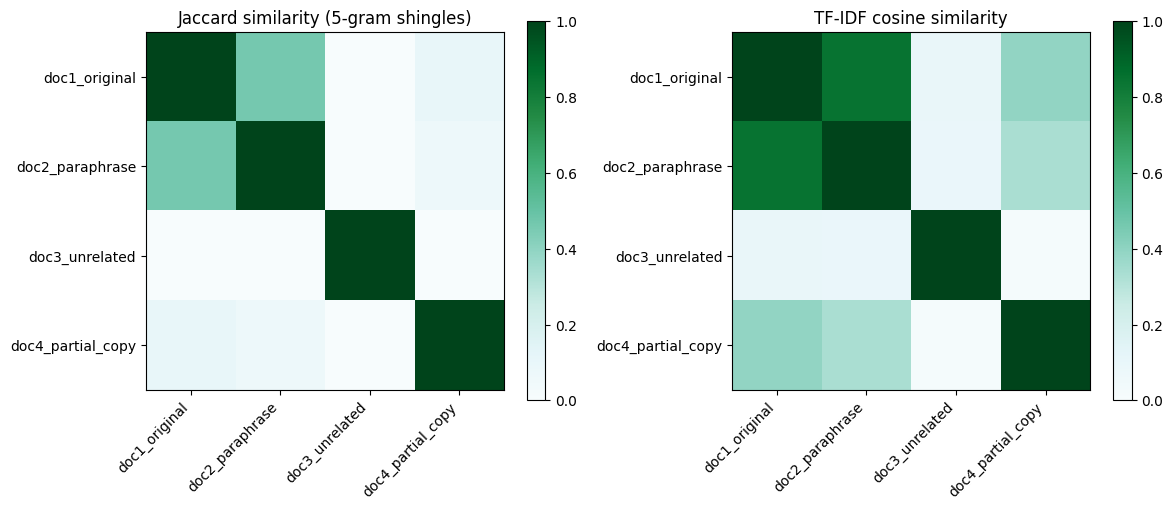

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(jaccard_matrix.values.astype(float), cmap="BuGn", vmin=0, vmax=1)
axes[0].set_xticks(range(len(names))); axes[0].set_xticklabels(names, rotation=45, ha="right")
axes[0].set_yticks(range(len(names))); axes[0].set_yticklabels(names)
axes[0].set_title(f"Jaccard similarity ({n}-gram shingles)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(cosine_sim, cmap="BuGn", vmin=0, vmax=1)
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=45, ha="right")
axes[1].set_yticks(range(len(names))); axes[1].set_yticklabels(names)
axes[1].set_title("TF-IDF cosine similarity")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## 5. Flag likely plagiarism pairs

In [6]:
THRESHOLD = 0.5
print("Pairs flagged as likely plagiarized (Jaccard >= 0.5):")
for i in range(len(names)):
    for j in range(i+1, len(names)):
        score = jaccard_matrix.iloc[i, j]
        if score >= THRESHOLD:
            print(f"  {names[i]} <-> {names[j]}: {score:.3f}")


Pairs flagged as likely plagiarized (Jaccard >= 0.5):


## Notes

- N-gram shingling + Jaccard is fast, exact-overlap-sensitive, and works well for
  catching near-verbatim copying — it's what the browser demo implements directly
  in JavaScript since it needs no training data.
- TF-IDF cosine similarity is more robust to synonym substitution and word reordering,
  since it weighs term importance across the whole corpus rather than requiring exact
  phrase matches — closer to how production tools like Turnitin operate at scale.
